# Install Some Libraries

In [1]:
# Might need sudo
# !apt-get update && apt-get install openjdk-8-jdk
# !pip -qq install datasets sentencepiece transformers py-vncorenlp sentence-transformers numpy seaborn


# Data Preparation

## Download dataset [Student Feedback](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback) from bkai

Datasets containing student review in Vietnamese and its corresponding class (Positive, Negative, Neutral).

We will download partially pre-processed, publicly available this dataset from [Huggingface](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback).


In [2]:
from datasets import load_dataset,Dataset

HUGGINGFACE_PATH = "uitnlp/vietnamese_students_feedback"
NUM_CORE = 2 # Colab Maximum Core

dataset = load_dataset(
    path=HUGGINGFACE_PATH,
    num_proc=NUM_CORE,
    split="train",
    verification_mode="no_checks",
    cache_dir="cache")

/home/rejk/miniconda3/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})

In [4]:
data_df=dataset.to_pandas()
data_df

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1
11422,em cảm ơn cô nhiều .,2,0
11423,giao bài tập quá nhiều .,0,0
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence   11426 non-null  object
 1   sentiment  11426 non-null  int64 
 2   topic      11426 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 267.9+ KB


<Axes: xlabel='sentiment', ylabel='count'>

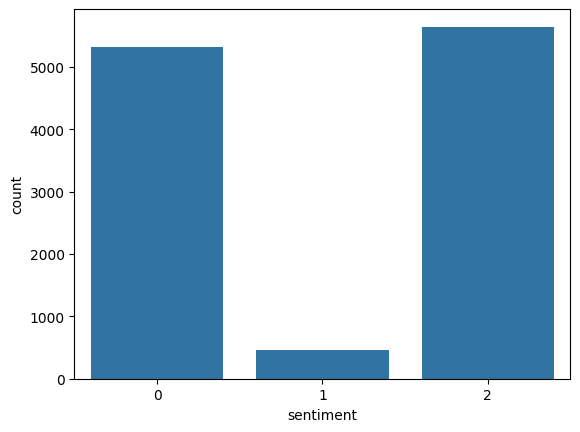

In [6]:
import seaborn as sns
sns.countplot(x='sentiment', data=data_df)
# 0 is negative, 1 is neutral, and 2 is positive

We will select sample a limited number of docs to finetune the model

In [7]:
NUM_SAMPLES = 10_000
# Filter out items with empty fields
fds=dataset.filter(lambda x: x['sentence'].strip())
# Sample 100,000 items at random
sub_dataset = fds.shuffle(seed=42).select(range(NUM_SAMPLES))

Download py_vncorenlp model

In [8]:
import py_vncorenlp
import os
VNCORENLP_SAVEDIR=os.path.abspath("cache/vncorenlp")
os.makedirs(VNCORENLP_SAVEDIR,exist_ok=True)
py_vncorenlp.download_model(save_dir=VNCORENLP_SAVEDIR)

VnCoreNLP model folder /home/rejk/Downloads/OneDrive_1_10-2-2024/cache/vncorenlp already exists! Please load VnCoreNLP from this folder!


### Preprocessing data: Tone normalization and Word segmentation

Warning: `py_vncorenlp` is a wrapper around the java package, once up and running it change the current directory to the location of the downloaded weights. Therefore, we need to change the working directory back to the initial destination. Otherwise, relative paths will be messed up.

In [10]:
import os 
# Save the current working dir
previous_working_dir=os.path.abspath(os.getcwd())

rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir=VNCORENLP_SAVEDIR)
tone_dict_map  =  {  "òa":  "oà",  "Òa":  "Oà",  "ÒA":  "OÀ",  "óa":  "oá",  "Óa":  "Oá",  "ÓA":  "OÁ",  "ỏa":  "oả",  "Ỏa":  "Oả",  "ỎA":  "OẢ",  "õa":  "oã",  "Õa":  "Oã",  "ÕA":  "OÃ",  "ọa":  "oạ",  "Ọa":  "Oạ",  "ỌA":  "OẠ",  "òe":  "oè",  "Òe":  "Oè",  "ÒE":  "OÈ",  "óe":  "oé",  "Óe":  "Oé",  "ÓE":  "OÉ",  "ỏe":  "oẻ",  "Ỏe":  "Oẻ",  "ỎE":  "OẺ",  "õe":  "oẽ",  "Õe":  "Oẽ",  "ÕE":  "OẼ",  "ọe":  "oẹ",  "Ọe":  "Oẹ",  "ỌE":  "OẸ",  "ùy":  "uỳ",  "Ùy":  "Uỳ",  "ÙY":  "UỲ",  "úy":  "uý",  "Úy":  "Uý",  "ÚY":  "UÝ",  "ủy":  "uỷ",  "Ủy":  "Uỷ",  "ỦY":  "UỶ",  "ũy":  "uỹ",  "Ũy":  "Uỹ",  "ŨY":  "UỸ",  "ụy":  "uỵ",  "Ụy":  "Uỵ",  "ỤY":  "UỴ",  }
def tone_normalize(text, dict_map=tone_dict_map):
    for i, j in dict_map.items():
        text = text.replace(i, j)
    return text
def preprocess_data(text):
    text=tone_normalize(text)
    return rdrsegmenter.word_segment(text)
# Since py_vncorenlp is a light wrapper around the Java package,
# it does not work out of the box with python multiprocessing.
# Therefore, it is recommended to word segment data before finetuning
# Or use another library (eg: pyvy) in case of training from scratch 
preprocessed_data=sub_dataset.map(lambda x:{
    "segmented":preprocess_data(x['sentence']),
})

# Return to the previous working dir
os.chdir(previous_working_dir)

Parameter 'function'=<function <lambda> at 0x7f4178cb37f0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


2024-10-02 15:19:34 INFO  WordSegmenter:24 - Loading Word Segmentation model


Map: 100%|██████████| 10000/10000 [00:07<00:00, 1416.15 examples/s]


In [11]:
preprocessed_data.to_json("./preprocessed_data.jsonl")

Creating json from Arrow format: 100%|██████████| 10/10 [00:00<00:00, 122.22ba/s]


2963590

# Load model

We wil load model and tokenizer from huggingface and test inferencing on our data

In [12]:
from transformers import AutoModel, AutoTokenizer
import torch
phobert = AutoModel.from_pretrained("vinai/phobert-base-v2",cache_dir="cache")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2",cache_dir="cache")

Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
input_data=load_dataset("json",data_files="./preprocessed_data.jsonl",cache_dir="cache",split="train")

Generating train split: 10000 examples [00:00, 437544.75 examples/s]


In [14]:
query=input_data[0]['segmented']
input_ids = torch.tensor([tokenizer.encode(query)])
print(query)
print(input_ids)

['các dụng_cụ thực_hành không được cung_cấp đầy_đủ .']
tensor([[0, 3, 2]])


In [15]:
output_vec = phobert(input_ids)
print(output_vec)

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.0748,  0.3523, -0.0780,  ..., -0.3801,  0.3803,  0.2272],
         [ 0.2090,  0.0154, -0.3883,  ..., -0.0663,  0.2109, -0.2869],
         [ 0.2682,  0.3079, -0.1737,  ..., -0.3522,  0.1819,  0.2824]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 4.9691e-02, -8.2380e-02, -4.4618e-02, -2.8366e-01,  3.6532e-01,
         -1.1426e-01, -1.6535e-01, -9.6101e-02,  1.1419e-01, -3.8840e-02,
         -3.0395e-02, -2.0921e-01,  2.4255e-01, -1.0669e-01,  2.9409e-01,
         -9.1989e-02,  1.9137e-01,  8.9028e-02, -6.9515e-02,  1.5082e-01,
         -1.7416e-01,  7.6546e-02, -9.0348e-02,  5.4070e-02,  1.0533e-01,
         -8.2112e-02,  6.3721e-02,  5.1224e-02,  2.1780e-01, -1.7107e-01,
          2.6365e-01,  6.8705e-02, -3.7920e-01,  9.9665e-02, -2.5812e-01,
         -8.2340e-02, -7.0255e-02,  1.0731e-01, -1.1909e-01, -3.7001e-02,
         -2.9927e-03,  1.2769e-01,  1.1150e-01,  1.6907e-01, -2.4664e-02

# Finetuning for sentimental analysis

Sentiment analysis is the process of analyzing text to determine if the emotional tone of the message is positive, negative, or neutral. We will use PhoBert to encode texts into vectors and classify them into the 3 sentimental classes.

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer
input_data=load_dataset("json",data_files="./preprocessed_data.jsonl",cache_dir="cache",split="train")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2",cache_dir="cache")
def tokenize_data(item):
    query=item['segmented']
    return tokenizer.encode_plus(query, truncation= True, max_length=256, padding='max_length', return_attention_mask=True, return_token_type_ids=False)
tokenized_dataset=input_data.map(tokenize_data)

Map: 100%|██████████| 10000/10000 [00:03<00:00, 3311.33 examples/s]


In [8]:
from torch import nn
from transformers import AutoModel
class SentimentClassifier(nn.Module):
    def __init__(self, n_classes=3):
        super(SentimentClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained("vinai/phobert-base-v2",cache_dir="cache")
        # self.tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2",cache_dir="cache")
        self.drop = nn.Dropout(p=0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)
        nn.init.normal_(self.fc.weight, std=0.02)
        nn.init.normal_(self.fc.bias, 0)

    def forward(self, input_ids, attention_mask):
        _, output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False # Dropout will errors if without this
        )

        x = self.drop(output)
        x = self.fc(x)
        return x

In [11]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import numpy as np
from tqdm import tqdm
import torch
model=SentimentClassifier()
model.train()
optimizer = AdamW(model.parameters(), lr=2e-5)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
EPOCHS=5
BATCH_SIZE=10
lr_scheduler = get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=0, 
            num_training_steps=len(tokenized_dataset)*EPOCHS
        )
DATASET_LEN=len(tokenized_dataset)
for epoch in range(EPOCHS):
    losses = []
    correct = 0
    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(u'\u2500' * 10)
    for i in tqdm(range(0,DATASET_LEN,BATCH_SIZE),desc=f'Epoch {epoch+1}/{EPOCHS}'):
        items=tokenized_dataset[i:min(i+BATCH_SIZE,DATASET_LEN)]
        input_ids = torch.tensor(items['input_ids']).to(device)
        attention_mask = torch.tensor(items['attention_mask']).to(device)
        targets = torch.tensor(items['sentiment']).to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, targets)
        _, pred = torch.max(outputs, dim=1)

        correct += torch.sum(pred == targets)
        losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()
    print(f'Train Accuracy: {correct.double()/DATASET_LEN} Loss: {np.mean(losses)}')

Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
──────────


Epoch 1/5:   0%|          | 0/1000 [00:00<?, ?it/s]

In [66]:
model.eval()
CLASS_MAP={0:"NEGATIVE",1:"NEUTRAL",2:"POSITIVE"}
def infer(text,device="cpu"):
    text = preprocess_data(text)
    
    tokenized_text = tokenizer(
        text,
        max_length=256,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='pt',
    )
    input_ids = tokenized_text['input_ids'].to(device)
    attention_mask = tokenized_text['attention_mask'].to(device)
    output = model(input_ids=input_ids,attention_mask=attention_mask)
    _, y_pred = torch.max(output, dim=1)
    return int(y_pred[0])
    
query="giảng viên giảng dạy hay"
result=infer(query)
print(f'Sentiment: {CLASS_MAP[result]}')

Sentiment: POSITIVE
